# 03 - Advanced Post-Cleaning Exploratory Data Analysis

This notebook validates the minimally cleaned gold table and investigates multivariate, temporal, distributional, and missingness patterns before modeling. It follows the initial raw-data EDA and the separate cleaning stage. No model features or chart files are saved.


## Analytical boundaries

Temporary bins, hour/day fields, and samples created here exist only inside this notebook for visualization. They are not written back to the gold table and are not automatically accepted as model features. Their predictive value must later be tested against the original-feature baseline.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.22
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the minimally cleaned table


In [2]:
BASE_DIR = Path.cwd() / "Code snippets" if (Path.cwd() / "Code snippets").exists() else Path.cwd()
INPUT_FILE = BASE_DIR / "gold_financial_fraud_detection_table.csv"
TARGET = "is_fraud"
TIMESTAMP = "event_timestamp"

DTYPE_MAP = {
    "transaction_id": "string", "transaction_type": "category",
    "merchant_category": "category", "location": "category",
    "device_used": "category", "payment_channel": "category",
    "amount": "float64", "time_since_last_transaction": "float64",
    "spending_deviation_score": "float64", "velocity_score": "int16",
    "geo_anomaly_score": "float64", "is_fraud": "int8",
}
EXPECTED_COLUMNS = ["transaction_id", "event_timestamp", "transaction_type", "merchant_category", "location", "device_used", "payment_channel", "amount", "time_since_last_transaction", "spending_deviation_score", "velocity_score", "geo_anomaly_score", "is_fraud"]
NUMERIC_COLUMNS = ["amount", "time_since_last_transaction", "spending_deviation_score", "velocity_score", "geo_anomaly_score"]
CATEGORICAL_COLUMNS = ["transaction_type", "merchant_category", "location", "device_used", "payment_channel"]

df = pd.read_csv(INPUT_FILE, dtype=DTYPE_MAP, parse_dates=[TIMESTAMP])
print("Loaded shape:", df.shape)
display(df.head())

Loaded shape: (5000000, 13)


,transaction_id,event_timestamp,transaction_type,merchant_category,location,device_used,payment_channel,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,is_fraud
0,T100000,2023-08-22 09:22:43.516168,withdrawal,utilities,Tokyo,mobile,card,343.78,NaN,-0.21,3,0.22,0
1,T100001,2023-08-04 01:58:02.606711,withdrawal,online,Toronto,atm,ACH,419.65,NaN,-0.14,7,0.96,0
2,T100002,2023-05-12 11:39:33.742963,deposit,other,London,pos,card,2773.86,NaN,-1.78,20,0.89,0
3,T100003,2023-10-10 06:04:43.195112,deposit,online,Sydney,pos,wire_transfer,1666.22,NaN,-0.60,6,0.37,0
4,T100004,2023-09-24 08:09:02.700162,transfer,utilities,Toronto,mobile,ACH,24.43,NaN,0.79,13,0.27,0


## 2. Reconcile the cleaning result

The output must agree with the initial EDA and the cleaning report before deeper analysis is trusted.


In [3]:
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
extra_columns = sorted(set(df.columns) - set(EXPECTED_COLUMNS))
fraud_count = int(df[TARGET].sum())
fraud_rate = float(df[TARGET].mean())

overview = pd.DataFrame([
    ("rows", len(df)), ("columns", df.shape[1]),
    ("date_min", df[TIMESTAMP].min()), ("date_max", df[TIMESTAMP].max()),
    ("fraud_count", fraud_count), ("fraud_rate_percent", fraud_rate * 100),
    ("missing_values_total", int(df.isna().sum().sum())),
    ("duplicate_transaction_ids", int(df["transaction_id"].duplicated().sum())),
    ("missing_expected_columns", missing_columns), ("unexpected_columns", extra_columns),
], columns=["metric", "value"])
display(overview)

schema = pd.DataFrame({
    "column": df.columns, "dtype": [str(x) for x in df.dtypes],
    "missing_count": df.isna().sum().to_numpy(),
    "missing_percent": (df.isna().mean() * 100).round(4).to_numpy(),
    "unique_count": df.nunique(dropna=True).to_numpy(),
})
display(schema)

,metric,value
0,rows,5000000
1,columns,13
2,date_min,2023-01-01 00:09:26.241974
3,date_max,2024-01-01 22:58:30.131850
4,fraud_count,179553
5,fraud_rate_percent,3.59106
6,missing_values_total,896513
7,duplicate_transaction_ids,0
8,missing_expected_columns,[]
9,unexpected_columns,[]


,column,dtype,missing_count,missing_percent,unique_count
0,transaction_id,string,0,0.0000,5000000
1,event_timestamp,datetime64[us],0,0.0000,4999998
2,transaction_type,category,0,0.0000,4
3,merchant_category,category,0,0.0000,8
4,location,category,0,0.0000,8
5,device_used,category,0,0.0000,4
6,payment_channel,category,0,0.0000,4
7,amount,float64,0,0.0000,217069
8,time_since_last_transaction,float64,896513,17.9303,4103487
9,spending_deviation_score,float64,0,0.0000,917


## 3. Missingness bias analysis

The raw EDA showed that `time_since_last_transaction` is missing only among non-fraud cases. Here we quantify the resulting target-rate difference. This may be a data-generation artifact, not genuine customer behavior.


,time_since_status,row_count,fraud_count,row_percent,fraud_rate_percent
0,missing,896513,0,17.9303,0.0000
1,observed,4103487,179553,82.0697,4.3756


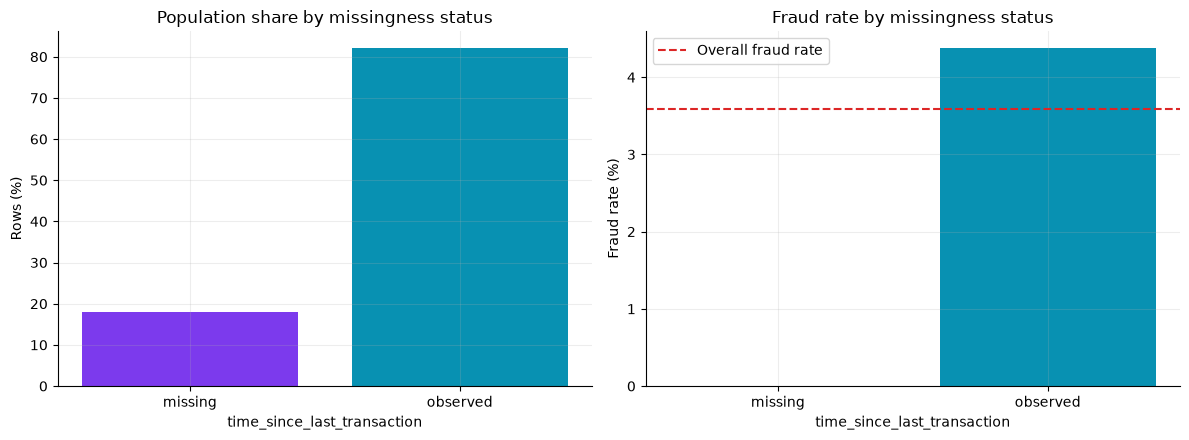

In [4]:
missingness_analysis = (
    df.assign(time_since_status=np.where(df["time_since_last_transaction"].isna(), "missing", "observed"))
      .groupby("time_since_status")
      .agg(row_count=(TARGET, "size"), fraud_count=(TARGET, "sum"))
      .reset_index()
)
missingness_analysis["row_percent"] = missingness_analysis["row_count"] / len(df) * 100
missingness_analysis["fraud_rate_percent"] = missingness_analysis["fraud_count"] / missingness_analysis["row_count"] * 100
display(missingness_analysis.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(missingness_analysis["time_since_status"], missingness_analysis["row_percent"], color=["#7c3aed", "#0891b2"])
axes[0].set(title="Population share by missingness status", ylabel="Rows (%)", xlabel="time_since_last_transaction")
axes[1].bar(missingness_analysis["time_since_status"], missingness_analysis["fraud_rate_percent"], color=["#7c3aed", "#0891b2"])
axes[1].axhline(fraud_rate * 100, color="#dc2626", linestyle="--", label="Overall fraud rate")
axes[1].set(title="Fraud rate by missingness status", ylabel="Fraud rate (%)", xlabel="time_since_last_transaction")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Distribution comparison by target using empirical CDFs

An empirical cumulative distribution function shows the entire amount distribution and is less sensitive to arbitrary histogram bins. A reproducible sample is used for rendering efficiency.


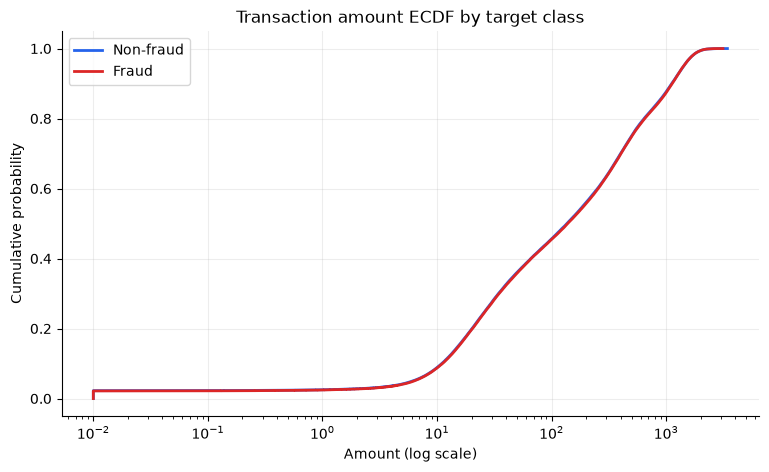

In [5]:
non_fraud_amount = df.loc[df[TARGET] == 0, "amount"].sample(n=200_000, random_state=42).to_numpy()
fraud_amount = df.loc[df[TARGET] == 1, "amount"].sample(n=min(200_000, fraud_count), random_state=42).to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
for values, label, color in [(non_fraud_amount, "Non-fraud", "#2563eb"), (fraud_amount, "Fraud", "#dc2626")]:
    ordered = np.sort(values)
    ecdf = np.arange(1, len(ordered) + 1) / len(ordered)
    ax.plot(ordered, ecdf, label=label, color=color, linewidth=2)
ax.set_xscale("log")
ax.set(title="Transaction amount ECDF by target class", xlabel="Amount (log scale)", ylabel="Cumulative probability")
ax.legend()
plt.show()

## 5. Fraud lift across amount quantiles

Twenty equal-frequency amount groups test whether particular parts of the amount distribution carry more fraud than the dataset average. Lift above 1 means above-average fraud concentration.


,quantile,amount_min,amount_max,row_count,fraud_rate,lift
0,1,0.01,6.16,250074,0.035306,0.983151
1,2,6.17,11.05,250019,0.035821,0.997513
2,3,11.06,15.46,250032,0.036419,1.014167
3,4,15.47,20.40,249979,0.036263,1.009815
4,5,20.41,26.57,250234,0.036218,1.008563
5,6,26.58,34.93,249790,0.036038,1.003555
6,7,34.94,47.44,250009,0.035639,0.992429
7,8,47.45,67.13,249896,0.037023,1.030988
8,9,67.14,97.22,250009,0.035295,0.982850
9,10,97.23,138.67,249998,0.035752,0.995591


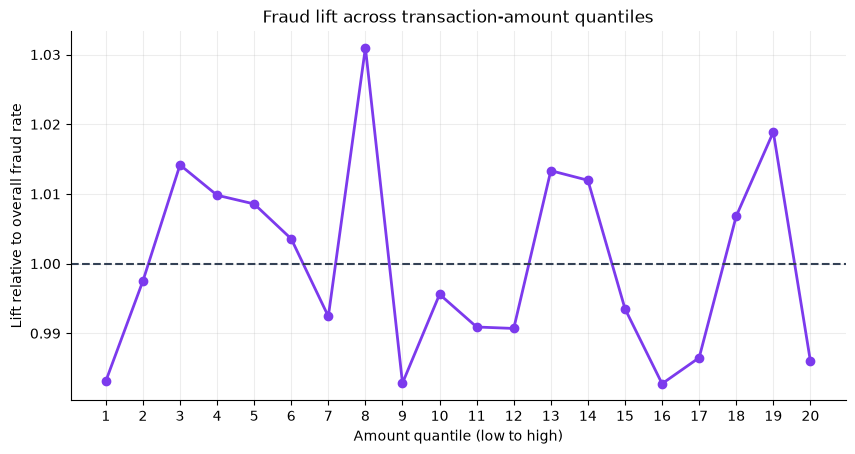

In [6]:
amount_quantile = pd.qcut(df["amount"], q=20, duplicates="drop")
amount_lift = (df.assign(amount_quantile=amount_quantile).groupby("amount_quantile", observed=True).agg(row_count=(TARGET, "size"), fraud_count=(TARGET, "sum"), amount_min=("amount", "min"), amount_max=("amount", "max")).reset_index())
amount_lift["fraud_rate"] = amount_lift["fraud_count"] / amount_lift["row_count"]
amount_lift["lift"] = amount_lift["fraud_rate"] / fraud_rate
amount_lift["quantile"] = np.arange(1, len(amount_lift) + 1)
display(amount_lift[["quantile", "amount_min", "amount_max", "row_count", "fraud_rate", "lift"]].round(6))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(amount_lift["quantile"], amount_lift["lift"], marker="o", color="#7c3aed", linewidth=2)
ax.axhline(1, color="#334155", linestyle="--")
ax.set(title="Fraud lift across transaction-amount quantiles", xlabel="Amount quantile (low to high)", ylabel="Lift relative to overall fraud rate", xticks=amount_lift["quantile"])
plt.show()

## 6. Categorical fraud rates with 95% Wilson confidence intervals

Raw rate rankings can exaggerate small differences. Wilson intervals show the uncertainty around each group rate and make it easier to judge whether apparent category differences are meaningful.


,feature,category,row_count,fraud_rate,ci_low,ci_high
0,transaction_type,payment,1250438,0.035640,0.035316,0.035966
1,merchant_category,utilities,624086,0.035670,0.035212,0.036133
2,device_used,mobile,1251131,0.035709,0.035386,0.036036
3,merchant_category,restaurant,625483,0.035760,0.035302,0.036223
4,location,Dubai,624320,0.035783,0.035325,0.036247
5,payment_channel,ACH,1250241,0.035784,0.035459,0.036111
6,merchant_category,online,623581,0.035800,0.035341,0.036264
7,transaction_type,deposit,1250593,0.035812,0.035488,0.036139
8,location,Tokyo,625994,0.035815,0.035358,0.036278
9,device_used,web,1250071,0.035844,0.035519,0.036171


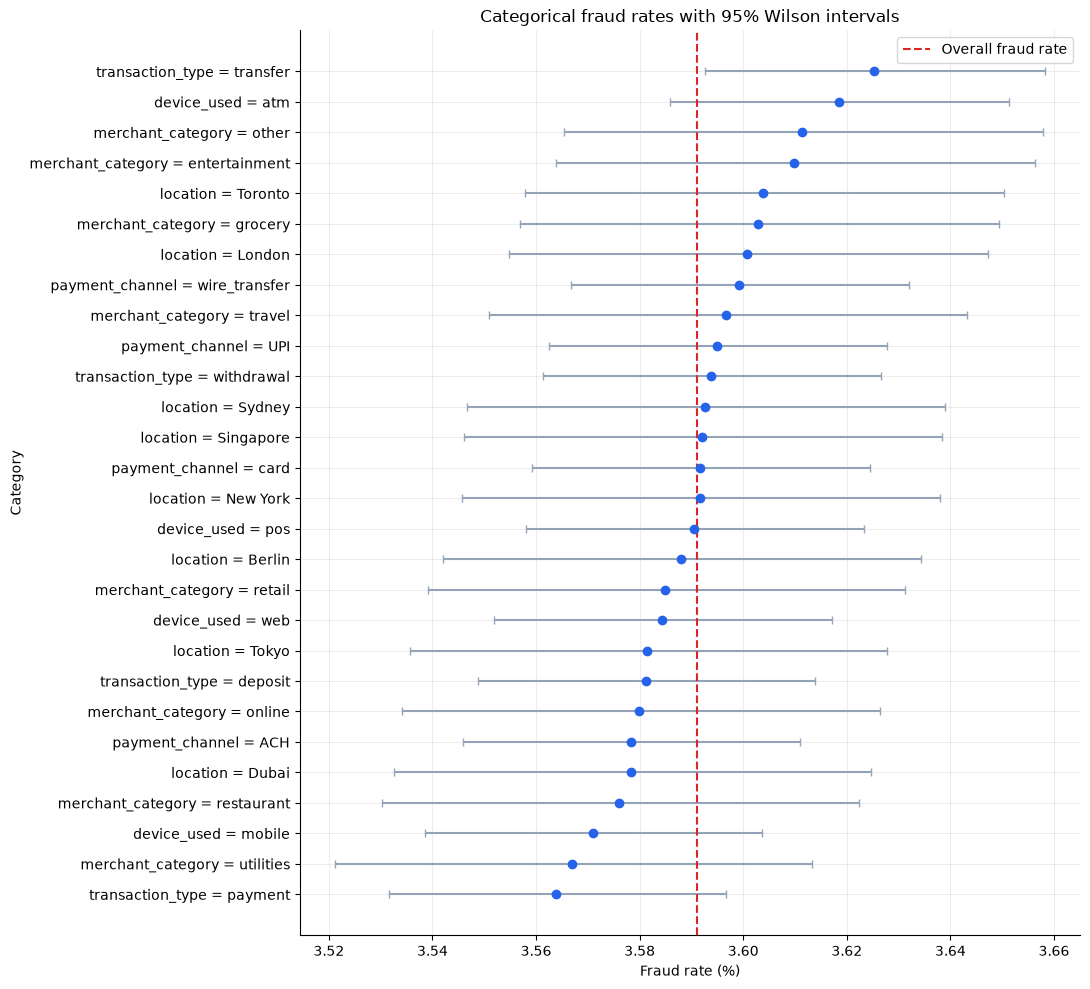

In [7]:
def wilson_interval(successes, totals, z=1.96):
    p = successes / totals
    denominator = 1 + z**2 / totals
    centre = (p + z**2 / (2 * totals)) / denominator
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * totals)) / totals) / denominator
    return centre - margin, centre + margin

category_parts = []
for column in CATEGORICAL_COLUMNS:
    part = df.groupby(column, observed=True).agg(row_count=(TARGET, "size"), fraud_count=(TARGET, "sum")).reset_index().rename(columns={column: "category"})
    part["feature"] = column
    part["fraud_rate"] = part["fraud_count"] / part["row_count"]
    part["ci_low"], part["ci_high"] = wilson_interval(part["fraud_count"], part["row_count"])
    category_parts.append(part)
category_rates = pd.concat(category_parts, ignore_index=True)
category_rates["label"] = category_rates["feature"] + " = " + category_rates["category"].astype(str)
category_rates = category_rates.sort_values("fraud_rate").reset_index(drop=True)
display(category_rates[["feature", "category", "row_count", "fraud_rate", "ci_low", "ci_high"]].round(6))

y = np.arange(len(category_rates))
x = category_rates["fraud_rate"].to_numpy() * 100
xerr = np.vstack([(category_rates["fraud_rate"] - category_rates["ci_low"]).to_numpy() * 100, (category_rates["ci_high"] - category_rates["fraud_rate"]).to_numpy() * 100])
fig, ax = plt.subplots(figsize=(11, 10))
ax.errorbar(x, y, xerr=xerr, fmt="o", color="#2563eb", ecolor="#94a3b8", capsize=3)
ax.axvline(fraud_rate * 100, color="#dc2626", linestyle="--", label="Overall fraud rate")
ax.set_yticks(y, category_rates["label"])
ax.set(title="Categorical fraud rates with 95% Wilson intervals", xlabel="Fraud rate (%)", ylabel="Category")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Hour-by-weekday fraud-rate heatmap

This two-dimensional view can reveal temporal interactions that separate hour or weekday summaries would miss. The derived fields exist only for analysis in this notebook.


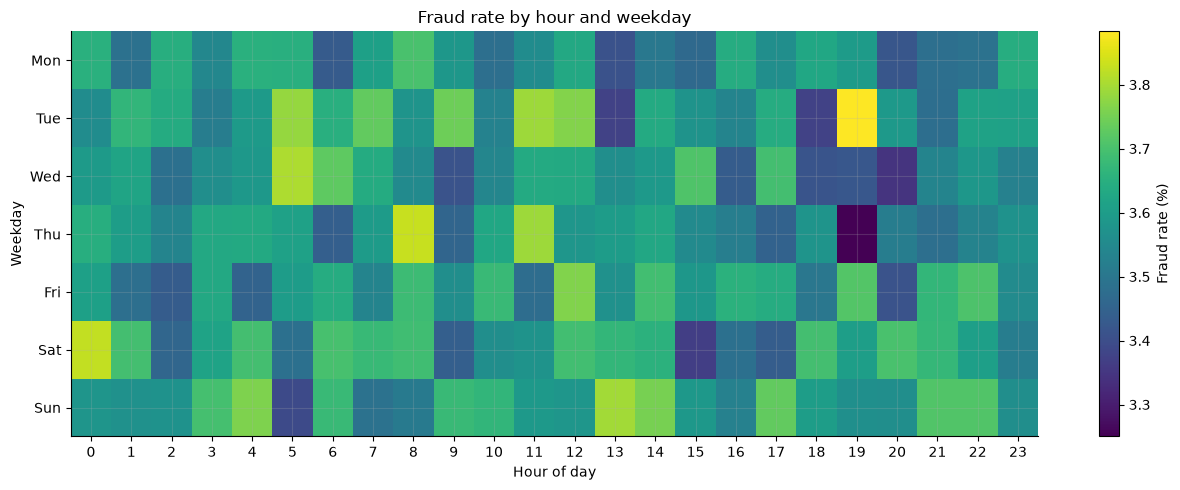

In [8]:
temporal = pd.DataFrame({TARGET: df[TARGET], "hour": df[TIMESTAMP].dt.hour, "weekday": df[TIMESTAMP].dt.dayofweek})
hour_weekday = temporal.groupby(["weekday", "hour"])[TARGET].mean().unstack("hour") * 100
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(13, 5))
image = ax.imshow(hour_weekday.to_numpy(), aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(24), np.arange(24))
ax.set_yticks(np.arange(7), weekday_names)
ax.set(title="Fraud rate by hour and weekday", xlabel="Hour of day", ylabel="Weekday")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Fraud rate (%)")
plt.tight_layout()
plt.show()

## 8. Weekly fraud-rate stability and transaction volume

A rolling weekly rate helps distinguish persistent temporal drift from random day-to-day noise. The final partial week is retained but should be interpreted cautiously.


,week,row_count,fraud_count,fraud_rate_percent,fraud_rate_4week_mean
0,2022-12-26,7285,252,3.459163,3.459163
1,2023-01-02,95765,3345,3.492925,3.476044
2,2023-01-09,95756,3417,3.568445,3.506844
3,2023-01-16,96430,3402,3.527948,3.512120
4,2023-01-23,95621,3413,3.569300,3.539654


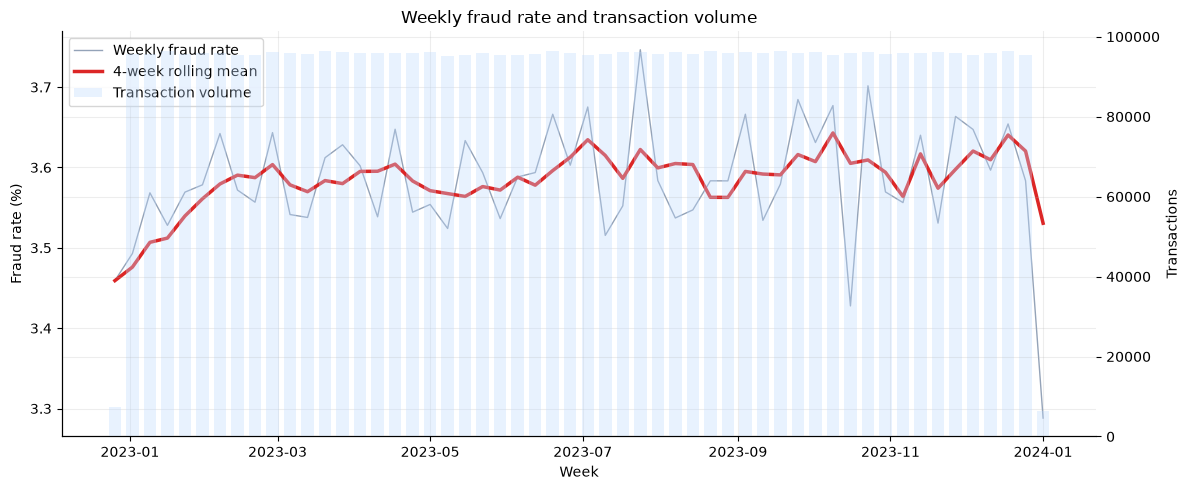

In [9]:
weekly = (df.assign(week=df[TIMESTAMP].dt.to_period("W").dt.start_time).groupby("week").agg(row_count=(TARGET, "size"), fraud_count=(TARGET, "sum")).reset_index())
weekly["fraud_rate_percent"] = weekly["fraud_count"] / weekly["row_count"] * 100
weekly["fraud_rate_4week_mean"] = weekly["fraud_rate_percent"].rolling(4, min_periods=1).mean()
display(weekly.head())

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(weekly["week"], weekly["fraud_rate_percent"], color="#94a3b8", linewidth=1, label="Weekly fraud rate")
ax1.plot(weekly["week"], weekly["fraud_rate_4week_mean"], color="#dc2626", linewidth=2.5, label="4-week rolling mean")
ax1.set(xlabel="Week", ylabel="Fraud rate (%)", title="Weekly fraud rate and transaction volume")
ax2 = ax1.twinx()
ax2.bar(weekly["week"], weekly["row_count"], width=5, color="#bfdbfe", alpha=0.35, label="Transaction volume")
ax2.set_ylabel("Transactions")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

## 9. Numeric correlation structure

This is a descriptive Pearson correlation matrix, not feature selection. It helps detect redundancy and obvious linear relationships among the available raw numeric predictors.


,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,is_fraud
amount,1.000000,0.000316,0.000799,-0.000811,0.000176,-0.000167
time_since_last_transaction,0.000316,1.000000,0.000202,0.000088,-0.000031,0.000014
spending_deviation_score,0.000799,0.000202,1.000000,-0.000155,0.000472,0.000201
velocity_score,-0.000811,0.000088,-0.000155,1.000000,0.000340,0.000370
geo_anomaly_score,0.000176,-0.000031,0.000472,0.000340,1.000000,0.000311
is_fraud,-0.000167,0.000014,0.000201,0.000370,0.000311,1.000000


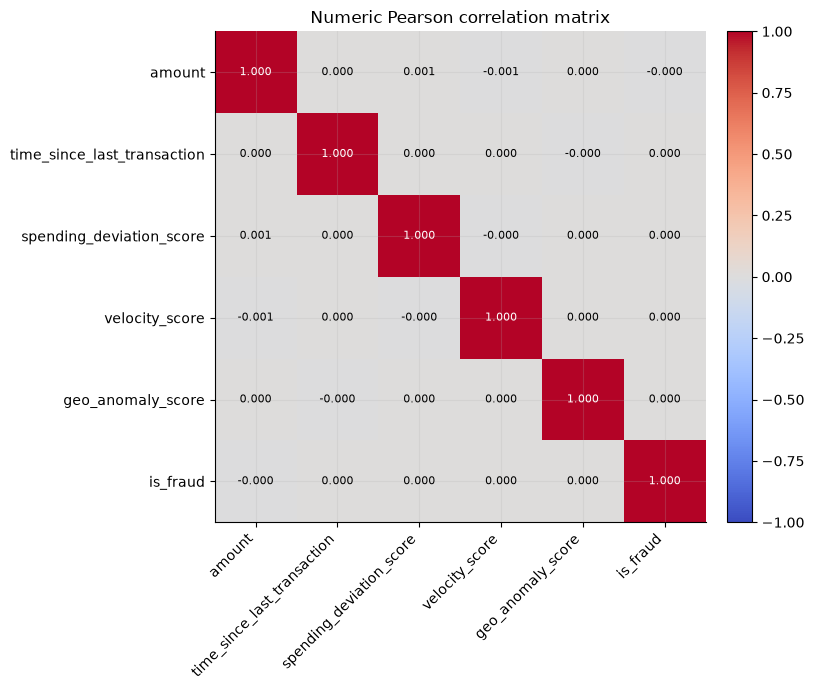

In [10]:
correlation = df[[*NUMERIC_COLUMNS, TARGET]].corr(numeric_only=True)
display(correlation.round(6))

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(correlation.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(correlation.columns)), correlation.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(correlation.index)), correlation.index)
for i in range(len(correlation.index)):
    for j in range(len(correlation.columns)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.3f}", ha="center", va="center", fontsize=8, color="white" if abs(correlation.iloc[i, j]) > 0.55 else "black")
ax.set_title("Numeric Pearson correlation matrix")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 10. Interaction surface between anomaly scores

A decile-by-decile fraud-rate surface tests whether combinations of behavioral deviation and geographic anomaly show structure that neither variable reveals alone. The bins are temporary analytical constructs.


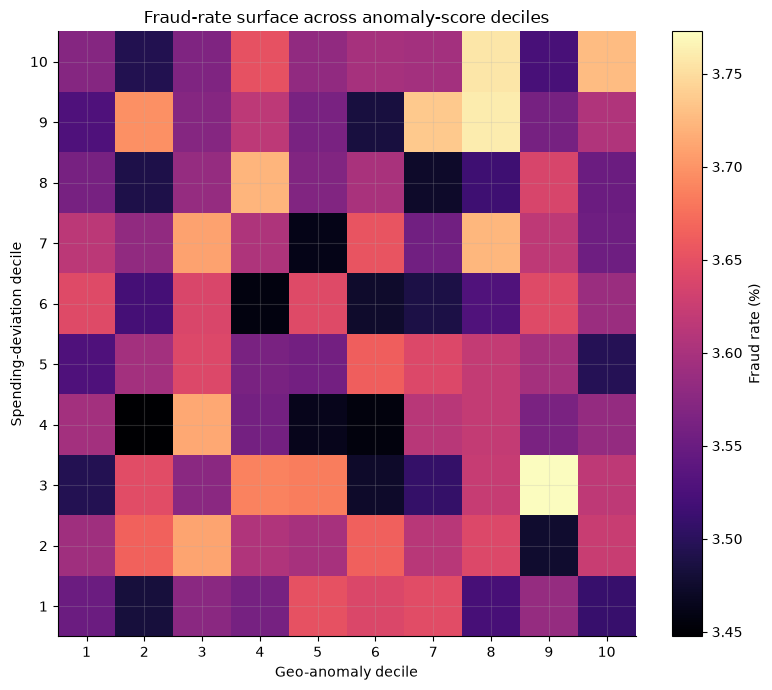

In [11]:
spending_decile = pd.qcut(df["spending_deviation_score"], q=10, labels=False, duplicates="drop")
geo_decile = pd.qcut(df["geo_anomaly_score"], q=10, labels=False, duplicates="drop")
interaction = (df.assign(spending_decile=spending_decile, geo_decile=geo_decile).groupby(["spending_decile", "geo_decile"])[TARGET].mean().unstack("geo_decile") * 100)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(interaction.to_numpy(), origin="lower", aspect="auto", cmap="magma")
ax.set_xticks(np.arange(interaction.shape[1]), np.arange(1, interaction.shape[1] + 1))
ax.set_yticks(np.arange(interaction.shape[0]), np.arange(1, interaction.shape[0] + 1))
ax.set(title="Fraud-rate surface across anomaly-score deciles", xlabel="Geo-anomaly decile", ylabel="Spending-deviation decile")
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Fraud rate (%)")
plt.tight_layout()
plt.show()

## 11. Evidence-based conclusions and modeling implications


In [12]:
amount_lift_range = amount_lift["lift"].max() - amount_lift["lift"].min()
category_rate_range = category_rates["fraud_rate"].max() - category_rates["fraud_rate"].min()
weekly_rate_range = weekly["fraud_rate_4week_mean"].max() - weekly["fraud_rate_4week_mean"].min()

advanced_findings = pd.DataFrame([
    ("Cleaning reconciliation", f"The gold table contains {len(df):,} rows and {df.shape[1]} columns; all raw transactions were preserved.", "Use this verified artifact for the baseline."),
    ("Class imbalance", f"Fraud represents {fraud_rate * 100:.4f}% of transactions.", "Use PR-AUC, precision, recall, F1, and threshold-aware evaluation."),
    ("Missingness bias", f"Missing time-since values occur in {df['time_since_last_transaction'].isna().mean() * 100:.2f}% of rows and have a {missingness_analysis.loc[missingness_analysis['time_since_status'] == 'missing', 'fraud_rate_percent'].iloc[0]:.4f}% fraud rate.", "Treat a missingness flag as a separate, sensitivity-tested feature because it may encode generation bias."),
    ("Amount distribution", f"The range of fraud lift across 20 amount quantiles is {amount_lift_range:.4f}.", "Keep raw amount in the baseline; test log amount separately rather than assuming benefit."),
    ("Categorical stability", f"The full categorical fraud-rate range is {category_rate_range * 100:.4f} percentage points.", "Use confidence intervals and validation performance before interpreting small category differences."),
    ("Temporal stability", f"The 4-week rolling fraud-rate range is {weekly_rate_range:.4f} percentage points.", "Use a time-aware split and test temporal features as a named experiment."),
    ("Numeric relationships", f"The strongest absolute raw-numeric correlation with the target is {correlation[TARGET].drop(TARGET).abs().idxmax()} ({correlation[TARGET].drop(TARGET).loc[correlation[TARGET].drop(TARGET).abs().idxmax()]:.6f}).", "Do not perform feature selection from full-data correlations; assess inside training only."),
], columns=["topic", "evidence", "implication"])
with pd.option_context("display.max_colwidth", None):
    display(advanced_findings)

,topic,evidence,implication
0,Cleaning reconciliation,"The gold table contains 5,000,000 rows and 13 columns; all raw transactions were preserved.",Use this verified artifact for the baseline.
1,Class imbalance,Fraud represents 3.5911% of transactions.,"Use PR-AUC, precision, recall, F1, and threshold-aware evaluation."
2,Missingness bias,Missing time-since values occur in 17.93% of rows and have a 0.0000% fraud rate.,"Treat a missingness flag as a separate, sensitivity-tested feature because it may encode generation bias."
3,Amount distribution,The range of fraud lift across 20 amount quantiles is 0.0482.,Keep raw amount in the baseline; test log amount separately rather than assuming benefit.
4,Categorical stability,The full categorical fraud-rate range is 0.0613 percentage points.,Use confidence intervals and validation performance before interpreting small category differences.
5,Temporal stability,The 4-week rolling fraud-rate range is 0.1838 percentage points.,Use a time-aware split and test temporal features as a named experiment.
6,Numeric relationships,The strongest absolute raw-numeric correlation with the target is velocity_score (0.000370).,Do not perform feature selection from full-data correlations; assess inside training only.


## Next stage

The next modeling stage should freeze a time-aware train/validation/test design, establish an original-feature baseline, and track every later feature experiment. This notebook supports those choices but does not make model-selection decisions.
